Найдено файлов: 2
Обрабатываю: approx_diesel_steam_CO_13-03-2026.csv


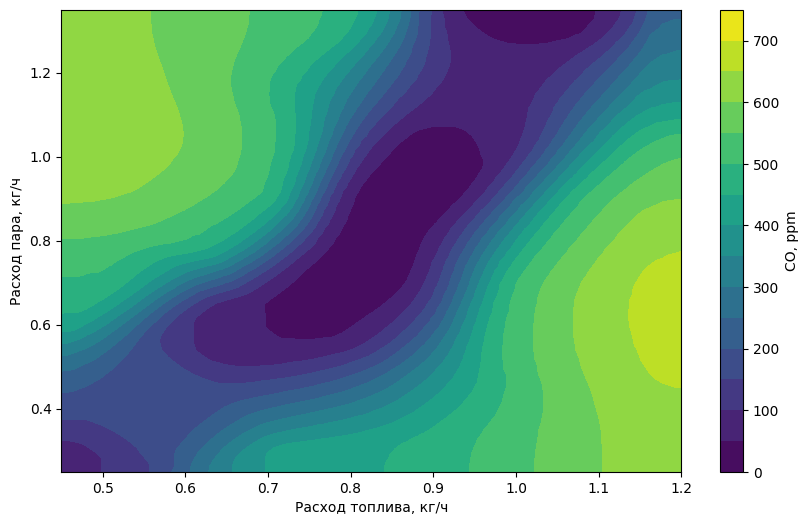

Обрабатываю: approx_waste_oil_steam_CO_13-03-2026.csv


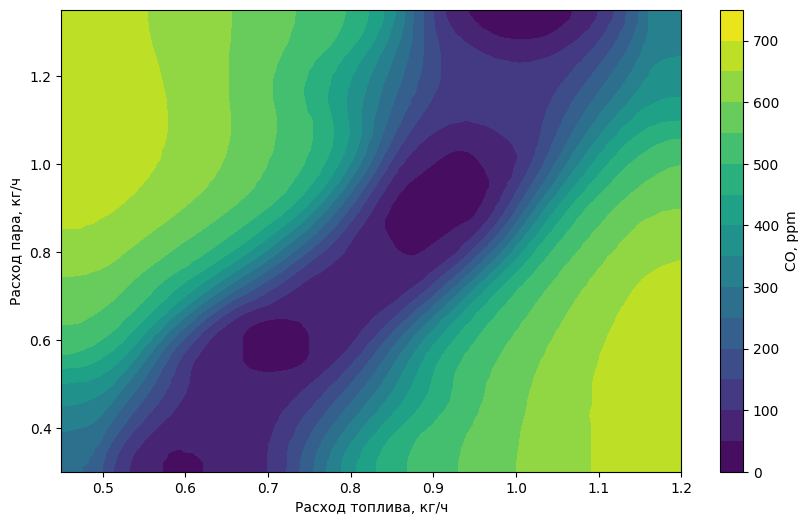

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob

# ====== Папка с файлами ======
folder = "C:/Users/evils/PycharmProjects/RegimeMap/result/13_03_2026"

csv_files = glob(os.path.join(folder, "*.csv"))
print(f"Найдено файлов: {len(csv_files)}")


# ====== Определяем подпись и диапазоны ======
def get_component_info(filename: str):
    """
    Возвращает:
    - label (подпись для colorbar)
    - levels (уровни для contourf)
    """

    name = filename.lower()

    if "o2" in name or "o_2" in name:
        label = r"O$_2$, об. %"
        levels = np.arange(0, 12 + 1.5, 1.5)
        return label, levels

    if "no" in name:
        label = "NO, об. %"
        levels = np.arange(0, 90 + 10, 10)
        return label, levels

    if "co" in name:
        label = "CO, ppm"
        levels = np.arange(0, 750 + 50, 50)
        return label, levels

    return "component", 10  # дефолтное число уровней


# ====== Построение графика ======
def plot_contour_from_df(df, title, component_label, levels):
    fuel = df["fuel"].values
    additive = df["additive"].values
    component = df["component"].values

    unique_add = df["additive"].unique()

    # --- Формирование поверхности ---
    if len(unique_add) == 1:
        add_val = unique_add[0]

        additive_grid = np.array([add_val - 0.01, add_val, add_val + 0.01])
        fuel_grid, additive_grid = np.meshgrid(fuel, additive_grid)
        component_grid = np.vstack([component, component, component])
    else:
        fuel_unique = np.sort(df["fuel"].unique())
        additive_unique = np.sort(df["additive"].unique())

        fuel_grid, additive_grid = np.meshgrid(fuel_unique, additive_unique)
        component_grid = np.full_like(fuel_grid, np.nan, dtype=float)

        for _, row in df.iterrows():
            i = np.where(additive_unique == row.additive)[0][0]
            j = np.where(fuel_unique == row.fuel)[0][0]
            component_grid[i, j] = row.component

    # --- Построение графика ---
    plt.figure(figsize=(10, 6))
    contour = plt.contourf(fuel_grid, additive_grid, component_grid, levels=levels)

    plt.colorbar(contour, label=component_label)
    plt.xlabel("Расход топлива, кг/ч")
    plt.ylabel("Расход пара, кг/ч")
    plt.show()


# ====== Основной цикл ======
for file in csv_files:
    df = pd.read_csv(file, sep=",")

    filename = os.path.basename(file)
    print(f"Обрабатываю: {filename}")

    component_label, levels = get_component_info(filename)

    plot_contour_from_df(df, title=filename, component_label=component_label, levels=levels)


Найдено файлов: 3
Обрабатываю: approx_diesel_steam_CO_old_burner.csv


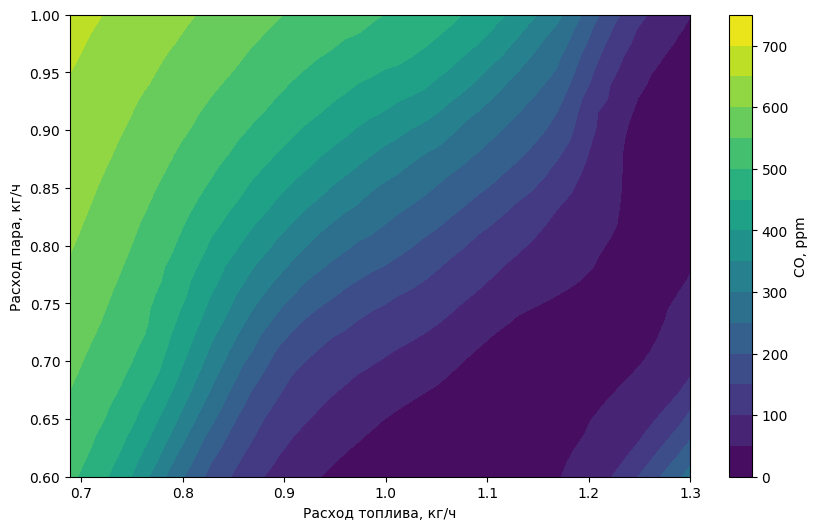

Обрабатываю: approx_diesel_steam_NO_old_burner.csv


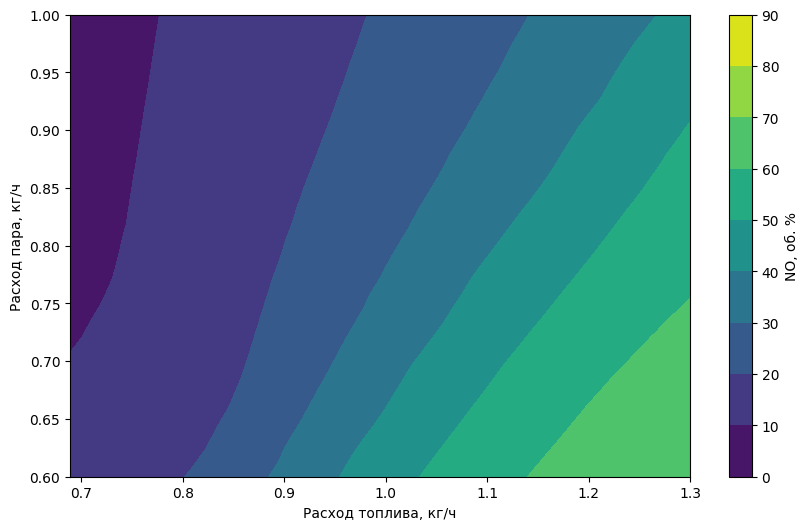

Обрабатываю: approx_diesel_steam_O2_old_burner.csv


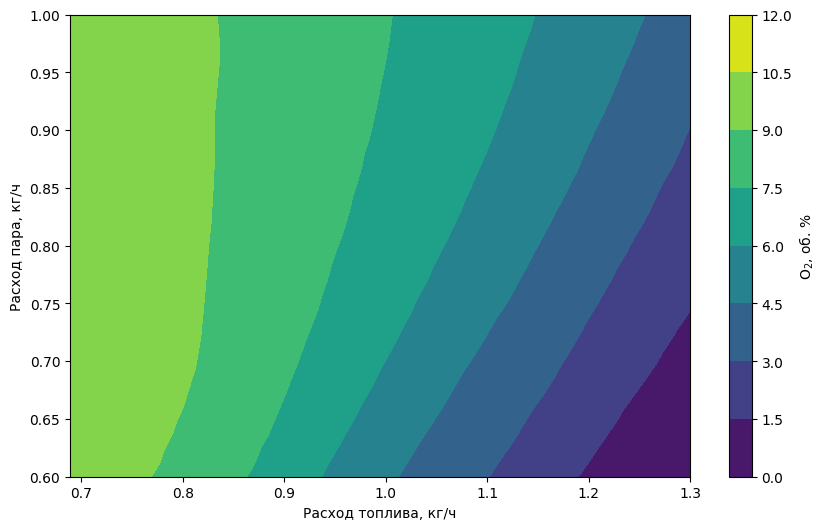

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob

# ====== Указываешь путь к папке ======
folder = "C:/Users/evils/PycharmProjects/RegimeMap/data/result/old_burner"

csv_files = glob(os.path.join(folder, "*.csv"))
print(f"Найдено файлов: {len(csv_files)}")


# ====== Определение подписи и уровней ======
def get_component_info(filename: str):
    """Возвращает (label, levels) по имени файла"""
    name = filename.lower()

    if "o2" in name or "o_2" in name:
        label = r"O$_2$, об. %"
        levels = np.arange(0, 12 + 1.5, 1.5)
        return label, levels

    if "no" in name:
        label = "NO, об. %"
        levels = np.arange(0, 90 + 10, 10)
        return label, levels

    if "co" in name:
        label = "CO, ppm"
        levels = np.arange(0, 750 + 50, 50)
        return label, levels

    return "component", 8  # по умолчанию 8 уровней


# ====== Функция построения графика ======
def plot_contour_from_df(df, title, component_label, levels):
    fuel = df["fuel"].values
    additive = df["additive"].values
    component = df["component"].values

    unique_add = df["additive"].unique()

    if len(unique_add) == 1:
        add_val = unique_add[0]

        additive_grid = np.array([add_val - 0.01, add_val, add_val + 0.01])
        fuel_grid, additive_grid = np.meshgrid(fuel, additive_grid)
        component_grid = np.vstack([component, component, component])
    else:
        fuel_unique = np.sort(df["fuel"].unique())
        additive_unique = np.sort(df["additive"].unique())

        fuel_grid, additive_grid = np.meshgrid(fuel_unique, additive_unique)
        component_grid = np.full_like(fuel_grid, np.nan, dtype=float)

        for _, row in df.iterrows():
            i = np.where(additive_unique == row.additive)[0][0]
            j = np.where(fuel_unique == row.fuel)[0][0]
            component_grid[i, j] = row.component

    plt.figure(figsize=(10, 6))

    # === применение levels, которые мы вычисляем автоматически ===
    contour = plt.contourf(fuel_grid, additive_grid, component_grid, levels=levels)

    plt.colorbar(contour, label=component_label)
    plt.xlabel("Расход топлива, кг/ч")
    plt.ylabel("Расход пара, кг/ч")

    # --- Установка пределов (оставляю как было) ---
    if "O$_2$" in component_label or "NO" in component_label or "CO" in component_label:
        plt.xlim(0.689, 1.3)
        plt.ylim(0.6, 1.00)

    plt.show()


# ====== Основной цикл ======
for file in csv_files:
    df = pd.read_csv(file, sep=",")

    filename = os.path.basename(file)
    print(f"Обрабатываю: {filename}")

    component_label, levels = get_component_info(filename)

    plot_contour_from_df(df, title=filename, component_label=component_label, levels=levels)
